In [1]:
pip install yfinance numpy scipy matplotlib plotly pandas

In [35]:
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
%matplotlib inline

# Scipy.stats
from scipy.stats import norm

# Random Generator
rng = np.random.default_rng(123)

import time
import yfinance as yf
import datetime as dt

In [20]:
def MC_options_vectorized(S, K, T, r, sigma, N, option_type='call'):
    """
    Vectorized Monte Carlo simulation for European options
    """
    # Generate random numbers
    X = rng.normal(0, 1, N)

    # Calculate stock prices at expiration
    ST = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * X)

    # Calculate discounted payoffs
    if option_type == 'call':
        payoffs = np.exp(-r * T) * np.maximum(ST - K, 0)
    else:  # put
        payoffs = np.exp(-r * T) * np.maximum(K - ST, 0)

    # Calculate price and variance
    price = np.mean(payoffs)
    variance = np.var(payoffs)

    return price, variance

In [36]:
# Testcase 2: Parameter imported from yahoo! finance
def fetch_options_data(ticker_symbol):
    ticker = yf.Ticker(ticker_symbol)
    options_dates = ticker.options

    # Use the farthest expiration date to get more reasonable options
    expiry_str = options_dates[-1]

    options_data = ticker.option_chain(expiry_str)

    # Get current stock price
    S = ticker.history(period="1d")["Close"].iloc[-1]

    return options_data.calls, options_data.puts, expiry_str, S

# Example usage:
calls, puts, expiry_str, S = fetch_options_data('JPM')

# Call option
atm_call = calls.iloc[(calls['strike'] - S).abs().argsort()[:1]] # pick the at-the-money strike from the nearest expiry
K_call = atm_call['strike'].values[0]

atm_put = puts.iloc[(puts['strike'] - S).abs().argsort()[:1]]
K_put = atm_put['strike'].values[0]

T = 1.0

# Get risk-free rate
r = yf.Ticker("^IRX").history(period="1d")["Close"].iloc[-1] / 100

# Use a reasonable implied volatility value (around 0.3 is typical for stocks)
sigma_call = 0.3
sigma_put = 0.3

print(f"S: {S:.6f}")
print(f"Call - K: {K_call}, T: {T:.6f}, r: {r:.6f}, σ: {sigma_call:.6f}")
print(f"Put - K: {K_put}, T: {T:.6f}, r: {r:.6f}, σ: {sigma_put:.6f}")

S: 311.750000
Call - K: 310.0, T: 1.000000, r: 0.038680, σ: 0.300000
Put - K: 310.0, T: 1.000000, r: 0.038680, σ: 0.300000


In [21]:
#Testcase1: Hardcode
S = 60
K_call = 65
K_put = 55
T = 1.0
r = 0.03
sigma_call = 0.3
sigma_put = 0.3


N = 10000
Call: 43.762676 ± 1.344741 (Error: 1.567757%)
Put: 29.907053 ± 0.798626 (Error: 1.362429%)
Computation time: 0.001063 seconds

N = 100000
Call: 43.382701 ± 0.432334 (Error: 0.508448%)
Put: 29.922559 ± 0.254510 (Error: 0.433960%)
Computation time: 0.014318 seconds

N = 1000000
Call: 43.538983 ± 0.136468 (Error: 0.159918%)
Put: 29.898234 ± 0.080355 (Error: 0.137124%)
Computation time: 0.110654 seconds

N = 10000000
Call: 43.489238 ± 0.043157 (Error: 0.050631%)
Put: 29.985110 ± 0.025454 (Error: 0.043310%)
Computation time: 1.309808 seconds

N = 100000000
Call: 43.519329 ± 0.013657 (Error: 0.016010%)
Put: 30.004903 ± 0.008050 (Error: 0.013689%)
Computation time: 11.180152 seconds


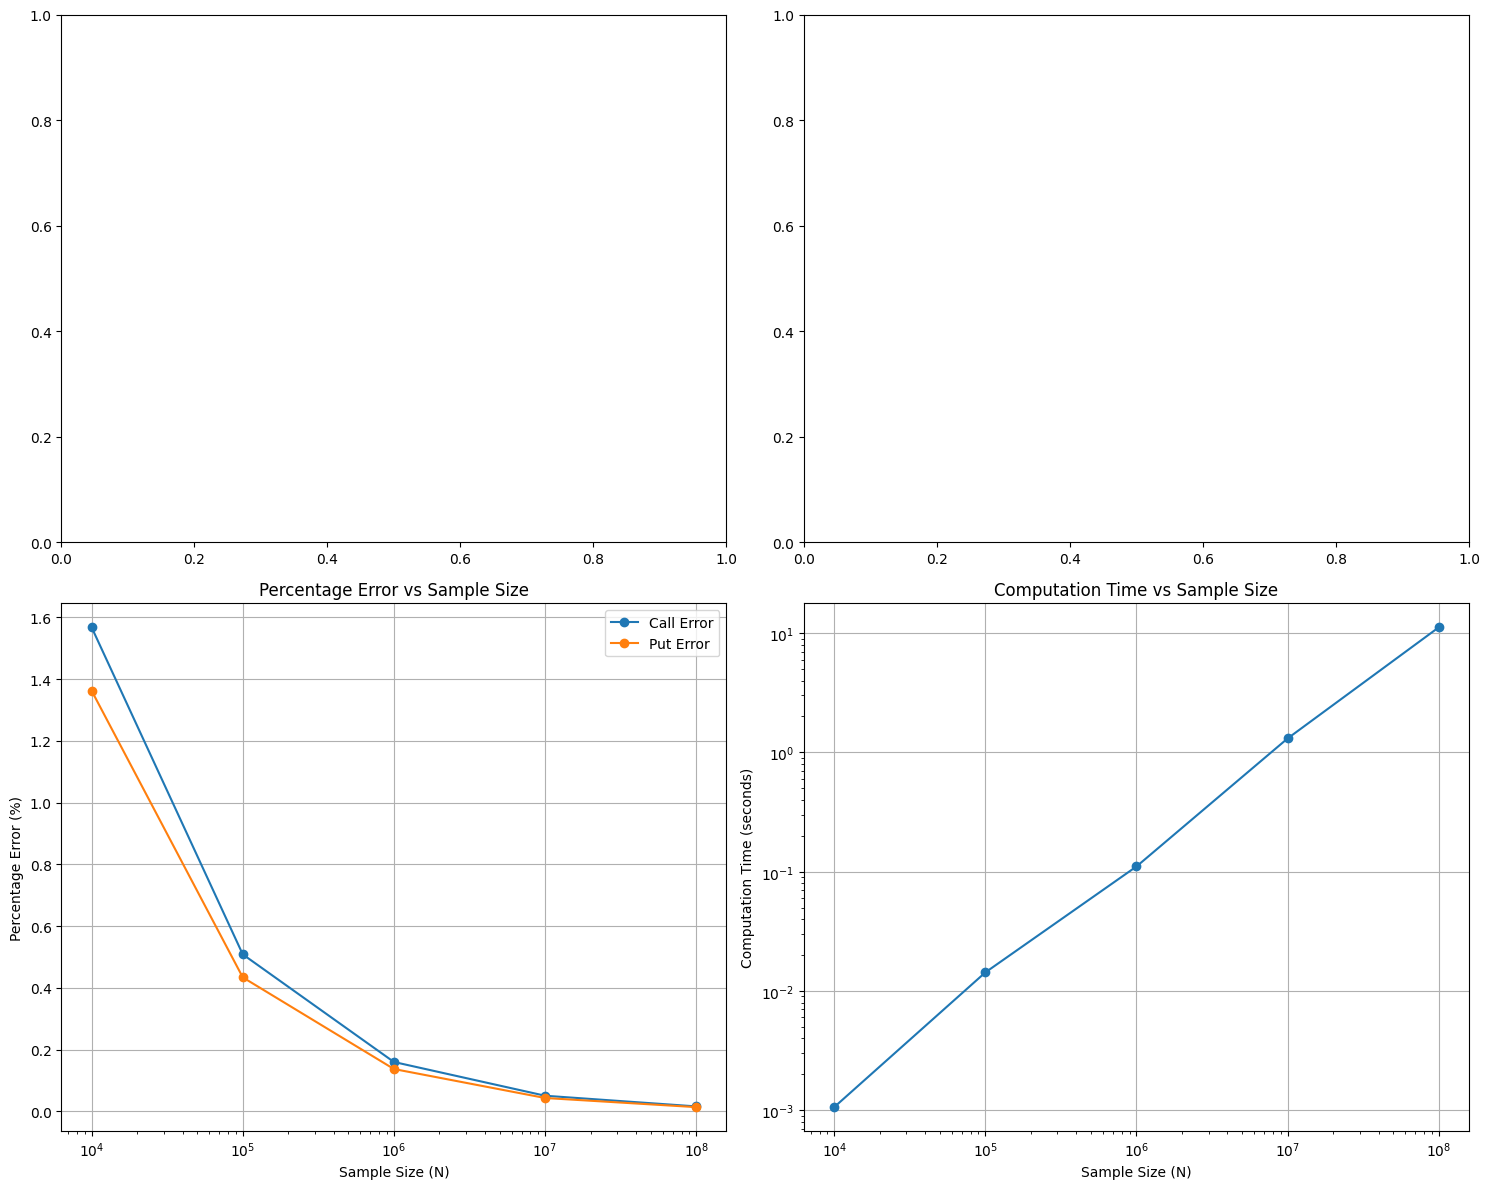


Percentage Errors:
Sample Size	Call Error (%)	Put Error (%)	Time (s)
10000		1.567757		1.362429		0.001063
100000		0.508448		0.433960		0.014318
1000000		0.159918		0.137124		0.110654
10000000		0.050631		0.043310		1.309808
100000000		0.016010		0.013689		11.180152

Standard Error of the Mean (SEM) Analysis:
Sample Size	Call SEM	Put SEM		1/sqrt(N)
10000		0.686093	0.407462	0.010000
100000		0.220579	0.129852	0.003162
1000000		0.069627	0.040998	0.001000
10000000		0.022019	0.012987	0.000316
100000000		0.006968	0.004107	0.000100


In [37]:
# Compare Monte Carlo estimates for different sample sizes
sample_sizes = [10**4, 10**5, 10**6, 10**7, 10**8] # max is 10**8 for this program

call_results = []
put_results = []
computation_times = []

for N in sample_sizes:
    start_time = time.time()

    # Call option
    MC_call_price, var_call = MC_options_vectorized(S, K_call, T, r, sigma_call, N, 'call')
    SEM_call = np.sqrt(var_call / N)
    perc_error_call = SEM_call / MC_call_price * 100 if MC_call_price > 0 else 0
    # use SEM_call instead of BS_call_price which is a true value, this is important for monte carlo

    # Put option
    MC_put_price, var_put = MC_options_vectorized(S, K_put, T, r, sigma_put, N, 'put')
    SEM_put = np.sqrt(var_put / N)
    perc_error_put = SEM_put / MC_put_price * 100 if MC_put_price > 0 else 0

    end_time = time.time()
    computation_time = end_time - start_time
    computation_times.append(computation_time)

    call_results.append({
        'N': N,
        'price': MC_call_price,
        'SEM': SEM_call,
        'perc_error': perc_error_call
    })

    put_results.append({
        'N': N,
        'price': MC_put_price,
        'SEM': SEM_put,
        'perc_error': perc_error_put
    })

    print(f"\nN = {N}")
    print(f"Call: {MC_call_price:.6f} ± {1.96*SEM_call:.6f} (Error: {perc_error_call:.6f}%)")
    print(f"Put: {MC_put_price:.6f} ± {1.96*SEM_put:.6f} (Error: {perc_error_put:.6f}%)")
    print(f"Computation time: {computation_time:.6f} seconds")

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Percentage error plot
ax3.semilogx(sample_sizes, [res['perc_error'] for res in call_results], 'o-', label='Call Error')
ax3.semilogx(sample_sizes, [res['perc_error'] for res in put_results], 'o-', label='Put Error')
ax3.set_xlabel('Sample Size (N)')
ax3.set_ylabel('Percentage Error (%)')
ax3.set_title('Percentage Error vs Sample Size')
ax3.legend()
ax3.grid(True)

# Computation time plot
ax4.loglog(sample_sizes, computation_times, 'o-')
ax4.set_xlabel('Sample Size (N)')
ax4.set_ylabel('Computation Time (seconds)')
ax4.set_title('Computation Time vs Sample Size')
ax4.grid(True)

plt.tight_layout()
plt.show()

# Display percentage errors
print("\nPercentage Errors:")
print("Sample Size\tCall Error (%)\tPut Error (%)\tTime (s)")
for i, N in enumerate(sample_sizes):
    print(f"{N}\t\t{call_results[i]['perc_error']:.6f}\t\t{put_results[i]['perc_error']:.6f}\t\t{computation_times[i]:.6f}")

# Additional analysis: Show how SEM decreases with sample size
print("\nStandard Error of the Mean (SEM) Analysis:")
print("Sample Size\tCall SEM\tPut SEM\t\t1/sqrt(N)")
for i, N in enumerate(sample_sizes):
    print(f"{N}\t\t{call_results[i]['SEM']:.6f}\t{put_results[i]['SEM']:.6f}\t{1/np.sqrt(N):.6f}")

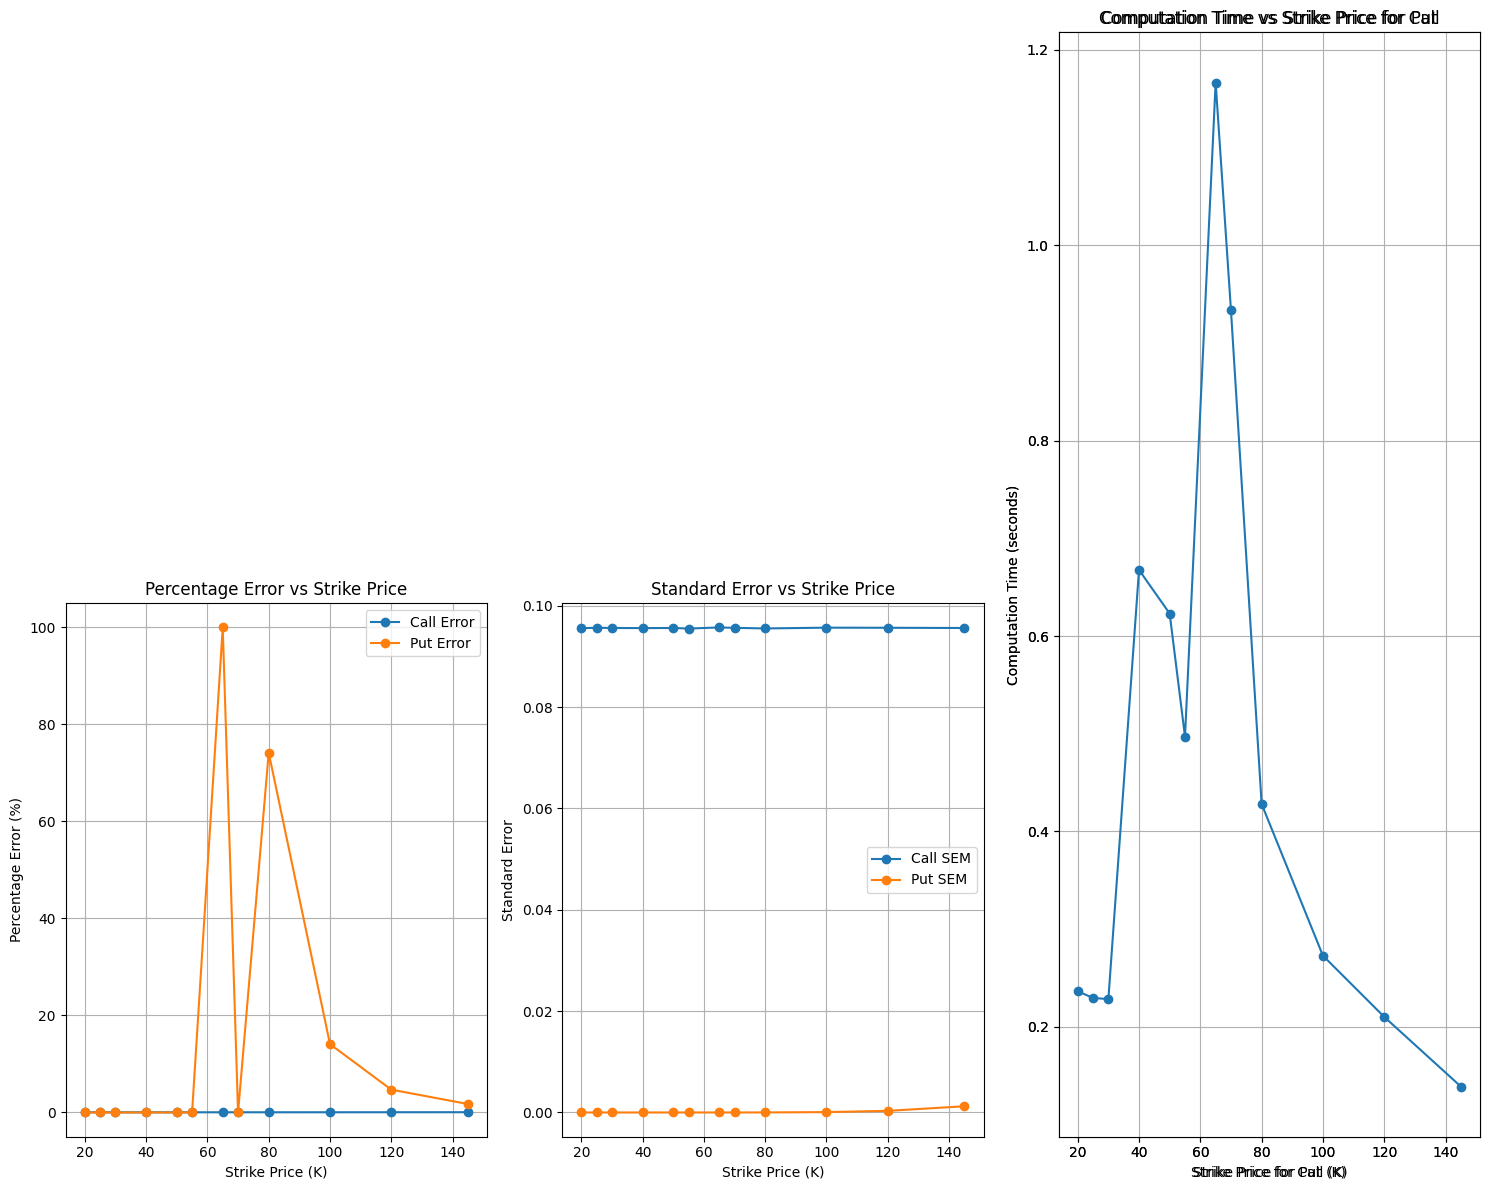


Detailed Results:
Strike		Call MC		Call Err%	Put MC		Put Err%	Time(s)
20.000000		292.482362	0.032679		0.000000	0.000000	0.236363
25.000000		287.705902	0.033251		0.000000	0.000000	0.229516
30.000000		282.996310	0.033789		0.000000	0.000000	0.228353
40.000000		273.336229	0.034973		0.000000	0.000000	0.667691
50.000000		263.608451	0.036274		0.000000	0.000000	0.623007
55.000000		258.756282	0.036911		0.000000	0.000000	0.496952
65.000000		249.204349	0.038413		0.000001	99.999950	1.166620
70.000000		244.505596	0.039120		0.000000	0.000000	0.933353
80.000000		234.733229	0.040697		0.000009	74.176766	0.428102
100.000000		215.610904	0.044378		0.000534	14.082517	0.272811
120.000000		196.225231	0.048751		0.006757	4.705155	0.210149
145.000000		172.278650	0.055502		0.070301	1.740978	0.138843


In [38]:
# Compare Monte Carlo estimates for different strike prices
# strike_range_call = [20,25,30,40,50,55]
# strike_range_put = [65,70,80,100,120,145]
strike_range = [20,25,30,40,50,55,65,70,80,100,120,145]

N = 10**6

call_results = []
put_results = []
computation_times = []

for K in strike_range:
    start_time = time.time()

    # Call option
    MC_call_price, var_call = MC_options_vectorized(S, K, T, r, sigma_call, N, 'call')
    SEM_call = np.sqrt(var_call / N)
    perc_error_call = (SEM_call/MC_call_price) * 100 if MC_call_price > 0 else 0

    # Put option
    MC_put_price, var_put = MC_options_vectorized(S, K, T, r, sigma_put, N, 'put')
    SEM_put = np.sqrt(var_put / N)
    perc_error_put = (SEM_put/MC_put_price) * 100 if MC_put_price > 0 else 0

    end_time = time.time()
    computation_time = end_time - start_time
    computation_times.append(computation_time)

    call_results.append({
        'K': K,
        'MC_price': MC_call_price,
        'SEM': SEM_call,
        'perc_error': perc_error_call
    })

    put_results.append({
        'K': K,
        'MC_price': MC_put_price,
        'SEM': SEM_put,
        'perc_error': perc_error_put
    })


fig = plt.figure(figsize=(15, 12))
gs = fig.add_gridspec(2, 3)

# Percentage error plot
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(strike_range, [res['perc_error'] for res in call_results],
         'o-', label='Call Error')
ax3.plot(strike_range, [res['perc_error'] for res in put_results],
         'o-', label='Put Error')
ax3.set_xlabel('Strike Price (K)')
ax3.set_ylabel('Percentage Error (%)')
ax3.set_title('Percentage Error vs Strike Price')
ax3.legend()
ax3.grid(True)

# Standard Error plot
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(strike_range, [res['SEM'] for res in call_results],
         'o-', label='Call SEM')
ax4.plot(strike_range, [res['SEM'] for res in put_results],
         'o-', label='Put SEM')
ax4.set_xlabel('Strike Price (K)')
ax4.set_ylabel('Standard Error')
ax4.set_title('Standard Error vs Strike Price')
ax4.legend()
ax4.grid(True)

# Computation time plot
ax5 = fig.add_subplot(gs[:, 2])
ax5.plot(strike_range, computation_times, 'o-')
ax5.set_xlabel('Strike Price for Call (K)')
ax5.set_ylabel('Computation Time (seconds)')
ax5.set_title('Computation Time vs Strike Price for Call')
ax5.grid(True)

ax5 = fig.add_subplot(gs[:, 2])
ax5.plot(strike_range, computation_times, 'o-')
ax5.set_xlabel('Strike Price for Put (K)')
ax5.set_ylabel('Computation Time (seconds)')
ax5.set_title('Computation Time vs Strike Price for Put')
ax5.grid(True)

plt.tight_layout()
plt.show()

print("\nDetailed Results:")
print("Strike\t\tCall MC\t\tCall Err%\tPut MC\t\tPut Err%\tTime(s)")
for i, K in enumerate(strike_range):
    print(f"{K:.6f}\t\t{call_results[i]['MC_price']:.6f}\t"
          f"{call_results[i]['perc_error']:.6f}\t\t{put_results[i]['MC_price']:.6f}\t"
          f"{put_results[i]['perc_error']:.6f}\t{computation_times[i]:.6f}")

